TASK SUCCESS Metric – Overview
Task Success in the HEART framework measures how well users can complete key actions — in Stack Overflow’s context, this could mean:

Questions getting answered

Accepted answers (users marking an answer as helpful)

Low ratio of unanswered or unresolved posts



What We’ll Do for Task Success (Step-by-Step):
Use the posts table only.

Filter for questions:

PostTypeId = 1 means the row is a question

Use AcceptedAnswerId to determine if the question was resolved:

If it's not null ⇒ success!

Group by YearMonth and calculate the % of resolved questions per month

Limit to 5,000,000 rows for now to stay memory-safe

Plot with Seaborn (viridis, year-grouped x-axis like you love 💚)

In [1]:
# === STEP 1: Import Libraries & Connect (if needed) ===
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
conn = sqlite3.connect("stackoverflow.db")

In [3]:
# === STEP 2: Load 5M Rows of Questions Only ===
query = """
    SELECT Id, CreationDate, AcceptedAnswerId
    FROM posts
    WHERE PostTypeId = 1 AND CreationDate IS NOT NULL
    LIMIT 5000000
"""
questions_df = pd.read_sql_query(query, conn)

In [4]:
print(f"Loaded rows: {len(questions_df)}")
print(questions_df.head())

Loaded rows: 5000000
   Id             CreationDate  AcceptedAnswerId
0   4  2008-07-31T21:42:52.667               7.0
1   6  2008-07-31T22:08:08.620              31.0
2   9  2008-07-31T23:40:59.743            1404.0
3  11  2008-07-31T23:55:37.967            1248.0
4  13  2008-08-01T00:42:38.903               NaN


In [5]:
# === STEP 3: Clean Dates & Define Task Success ===
questions_df["CreationDate"] = pd.to_datetime(questions_df["CreationDate"], errors="coerce")
questions_df = questions_df.dropna(subset=["CreationDate"])
questions_df = questions_df[questions_df["CreationDate"] <= pd.Timestamp(datetime.today())]
questions_df["YearMonth"] = questions_df["CreationDate"].dt.to_period("M").astype(str)
questions_df["Resolved"] = questions_df["AcceptedAnswerId"].notna()

In [6]:
# === STEP 4: Calculate Task Success Rate Per Month ===
success_stats = (
    questions_df.groupby("YearMonth")["Resolved"]
    .agg(["count", "sum"])
    .rename(columns={"count": "TotalQuestions", "sum": "ResolvedQuestions"})
    .reset_index()
)
success_stats["SuccessRate"] = (success_stats["ResolvedQuestions"] / success_stats["TotalQuestions"]) * 100


C:\Users\Ola\AppData\Local\Temp\ipykernel_13524\1274459879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="YearMonth", y="SuccessRate", data=success_stats, palette="viridis")
C:\Users\Ola\AppData\Local\Temp\ipykernel_13524\1274459879.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(year_month_pattern)


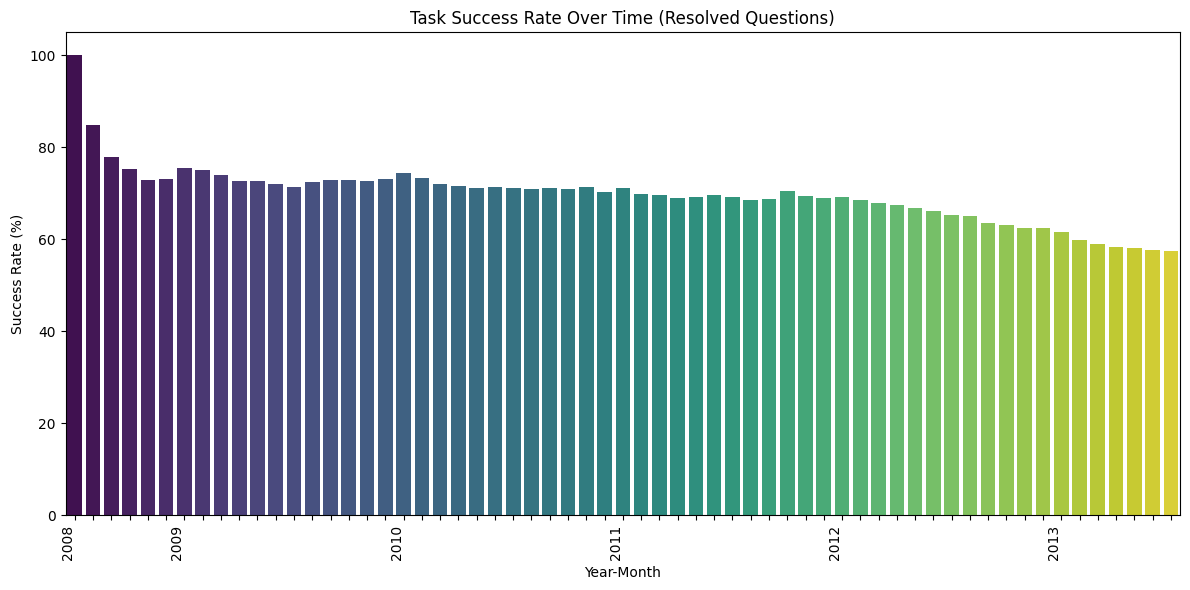

In [7]:
# === STEP 5: Plot Task Success Over Time ===
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="YearMonth", y="SuccessRate", data=success_stats, palette="viridis")

plt.title("Task Success Rate Over Time (Resolved Questions)")
plt.xlabel("Year-Month")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=90, ha='right')

# Grouped year labels
year_month_pattern = []
unique_years = success_stats["YearMonth"].str.split("-").str[0].unique()

for year in unique_years:
    year_month_pattern.append(year)
    year_month_pattern.extend([' '] * (success_stats["YearMonth"].str.startswith(year).sum() - 1))

ax.set_xticklabels(year_month_pattern)

plt.tight_layout()
plt.show()


https://chatgpt.com/g/g-tNwCg2vYv-python/c/67f4ec2b-0394-8005-a48a-01679fb01961

add more from: Follow-Up 1: How Many Questions Get Answers (Not Just Accepted)?

Follow-Up 2: Unanswered Question Ratio

Follow-Up 3: Trend in Volume vs Success